In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:


def get_infect_prob(contact_rate, Beta, days_infectious):
    numerator = contact_rate / (1 - contact_rate) * np.exp(Beta * (days_infectious**3 - 1))
    return numerator / (1 + numerator)

In [3]:


class Agent:
    def __init__(self, node_id, exposed_dist, infectious_dist, contact_rate, Beta, initial_state='S'):
        self.node_id = node_id
        self.countdown_to_infectious = np.ceil(exposed_dist.rvs())
        self.countdown_to_recovery = np.ceil(infectious_dist.rvs())
        self.days_spent_infectious = 0
        self.state = initial_state
        self.Beta = Beta
        self.contact_rate = contact_rate

    def infect_neighbors(self, G, agent_map):
        infect_prob = get_infect_prob(self.contact_rate, self.Beta, self.days_spent_infectious)
        neighbor_ids = list(G.neighbors(self.node_id))
        
        for n_id in neighbor_ids:
            neighbor_agent = agent_map[n_id]
            if neighbor_agent.state == 'S' and np.random.rand() < infect_prob:
                neighbor_agent.state = 'E'

    def update(self, G, agent_map):
        match self.state:
            case 'S':
                pass
            case 'E':
                self.countdown_to_infectious -= 1
                if self.countdown_to_infectious <= 0:
                    self.state = 'I'
            case 'I':
                self.days_spent_infectious += 1
                self.countdown_to_recovery -= 1
                if self.countdown_to_recovery <= 0:
                    self.state = 'R'
                else:
                    self.infect_neighbors(G, agent_map)
            case 'R':
                pass


In [36]:
class Population:
    def __init__(self, G, contact_rate=0.12, Beta=-0.00504, exposed_dist=None, infectious_dist=None, p_succeptible=None, p_exposed=None, p_infectious=None):
        self.n = G.number_of_nodes()
        self.G = G
        self.history = {'S': [], 'E': [], 'I': [], 'R': []}
        if exposed_dist is None:
            exposed_dist = stats.lognorm(1.0, 1.0)
        if infectious_dist is None:
            infectious_dist = stats.lognorm(2.25, 0.105)

        match sum([p_succeptible is None, p_exposed is None, p_infectious is None]):
            case 3:
                p_succeptible = 0.90
                p_exposed = 0.05
                p_infectious = 0.05
            case 2: 
                raise ValueError("Must specify 0, 2, or 3 of the initial probabilities")
            case 1:
                props = [p_succeptible, p_exposed, p_infectious]
                props[props == None] = 1 - props[props != None].sum()
                p_succeptible, p_exposed, p_infectious = props
            case 0:
                if abs(sum([p_succeptible, p_exposed, p_infectious]) - 1) > 1e-10:
                    raise ValueError("Initial probabilities must sum to 1")
                p_succeptible = 1 - p_exposed - p_infectious

        n_succeptible = round(p_succeptible * self.n)
        n_exposed = round(p_infectious * self.n)
        n_infectious = self.n - n_succeptible - n_exposed

        initial_states = ['S'] * n_succeptible + ['E'] * n_exposed + ['I'] * n_infectious
        np.random.shuffle(initial_states)

        self.agent_map = {}
        for node_id, initial_state in zip(G.nodes(), initial_states):
            agent = Agent(node_id, exposed_dist, infectious_dist, contact_rate, Beta, initial_state)
            self.agent_map[node_id] = agent

        self.history['S'].append(n_succeptible)
        self.history['E'].append(n_exposed)
        self.history['I'].append(n_infectious)
        self.history['R'].append(0)

    def update(self):
        for agent in self.agent_map.values():
            agent.update(self.G, self.agent_map)
        n_succeptible, n_exposed, n_infectious, n_recovered = self.get_characteristics()
        self.history['S'].append(n_succeptible)
        self.history['E'].append(n_exposed)
        self.history['I'].append(n_infectious)
        self.history['R'].append(n_recovered)

    def get_history(self):
        return self.history

    def get_characteristics(self):
        n_succeptible, n_exposed, n_infectious, n_recovered = 0, 0, 0, 0
        for agent in self.agent_map.values():
            match agent.state:
                case 'S':
                    n_succeptible += 1
                case 'E':
                    n_exposed += 1
                case 'I':
                    n_infectious += 1
                case 'R':
                    n_recovered += 1
        
        return n_succeptible, n_exposed, n_infectious, n_recovered

    def draw(self):
        color_map = {'S': 'green', 'E': 'yellow', 'I': 'red', 'R': 'blue'}
        node_colors = [color_map[self.agent_map[node_id].state] for node_id in self.G.nodes()]
        nx.draw_kamada_kawai(self.G, with_labels=False, node_color=node_colors, node_size = 80)


In [37]:
from scipy.io import mmread
dublin = nx.Graph(mmread('ia-infect-dublin.mtx'))

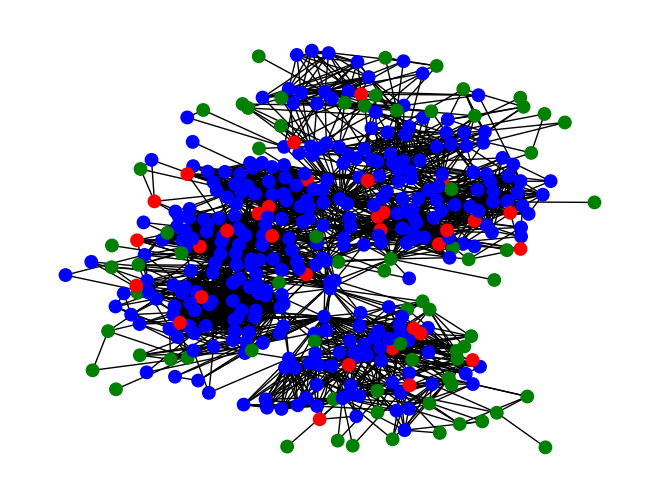

In [38]:

G = dublin.copy()
pop = Population(G)
for _ in range(40):
    pop.update()
pop.draw()

In [10]:
networks = {
    "Dublin": dublin,
    "Circ2": nx.circulant_graph(20, [1, 2]),
    "Circ4": nx.circulant_graph(20, [1, 2, 3, 4]),
    "Complete": nx.complete_graph(100),
    "Grid": nx.grid_2d_graph(10, 10),
    "Scale100": nx.barabasi_albert_graph(100, 3),
    "Scale410": nx.barabasi_albert_graph(410, 3)
}

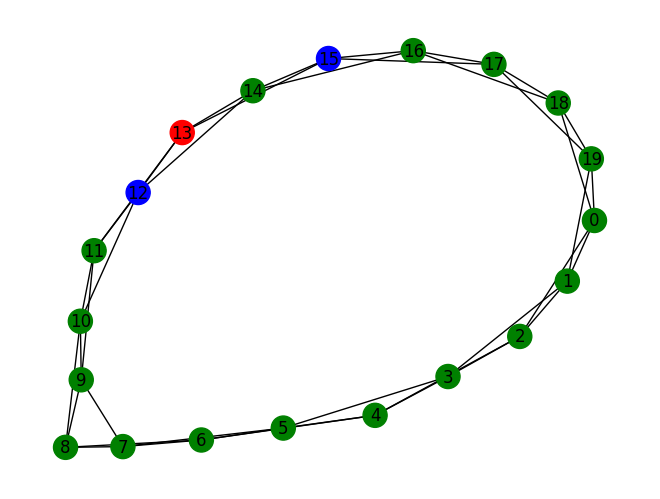

In [14]:
G = networks["Circ2"].copy()

pop = Population(G)
for _ in range(40):
    pop.update()
pop.draw()

In [59]:
default_parameters = {
    "contact_rate": 0.12,
    "Beta": -0.00504,
    "exposed_dist": stats.lognorm(1.0, 1.0),
    "infectious_dist": stats.lognorm(2.25, 0.105)
}
my_parameters = {
    "contact_rate": 0.5,
    "Beta": -0.00504,
    "exposed_dist": stats.lognorm(scale=720, s=900),
    "infectious_dist": stats.lognorm(scale=26, s=10)
}
all_parameters = [default_parameters, my_parameters]

In [60]:
def do_experiment(network, parameters, T=40):
    G = network.copy()
    pop = Population(G, **parameters)
    for _ in range(T):
        pop.update()
    return pop.get_history()


In [61]:
def pull_summary(histories, key):
    specific_history = [h[key] for h in histories]
    return np.mean(specific_history, axis=0), np.percentile(specific_history, [25, 75], axis=0)


def aggregate_histories(histories):
    # Get mean, 25th, and 75th percentiles 
    # across all histories at each timestep
    # for each key in the history
    summary = {}
    for key in histories[0].keys():
        summary[key] = pull_summary(histories, key)
    return summary

In [64]:
def plot_many_experiments(network_name, histories, logx = False):
    plt.figure(figsize=(10, 6))
    plt.title(network_name)
    summary = aggregate_histories(histories)
    for key, (mean, percentiles) in summary.items():
        plt.plot(mean, label=key)
        if logx:
            plt.xscale('log')
        plt.fill_between(range(len(mean)), percentiles[0], percentiles[1], alpha=0.2)

    plt.legend()
    plt.ylabel("# of Individuals")
    plt.xlabel("Time Step")
    plt.show()



Starting Complete


/Users/phr23/Code/cs-575/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:6864: RuntimeWarning: overflow encountered in exp
  return np.exp(s * random_state.standard_normal(size))
/Users/phr23/Code/cs-575/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:1133: RuntimeWarning: overflow encountered in multiply
  vals = vals * scale + loc
/Users/phr23/Code/cs-575/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


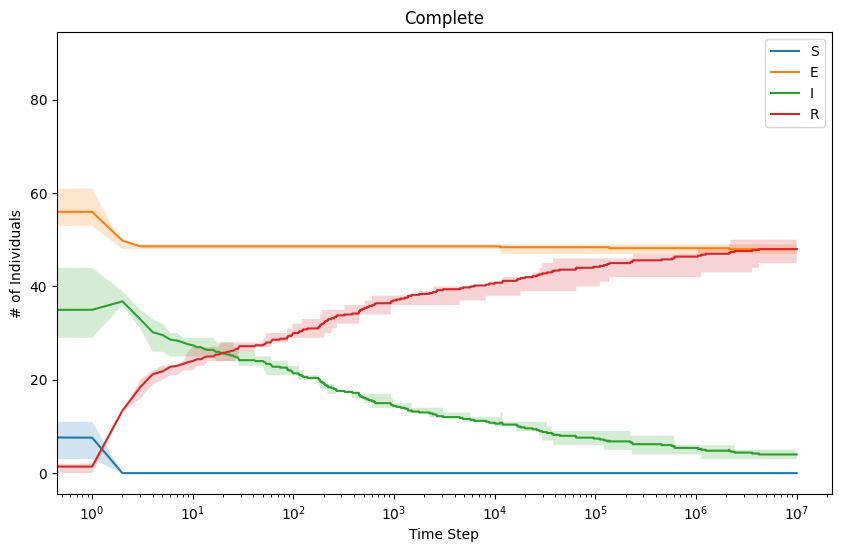

In [81]:
name, G = "Complete", networks["Complete"]
print(f"Starting {name}")
histories = [do_experiment(G, my_parameters, 10000000) for _ in range(5)]
plot_many_experiments(name, histories, logx=True)

Starting Dublin


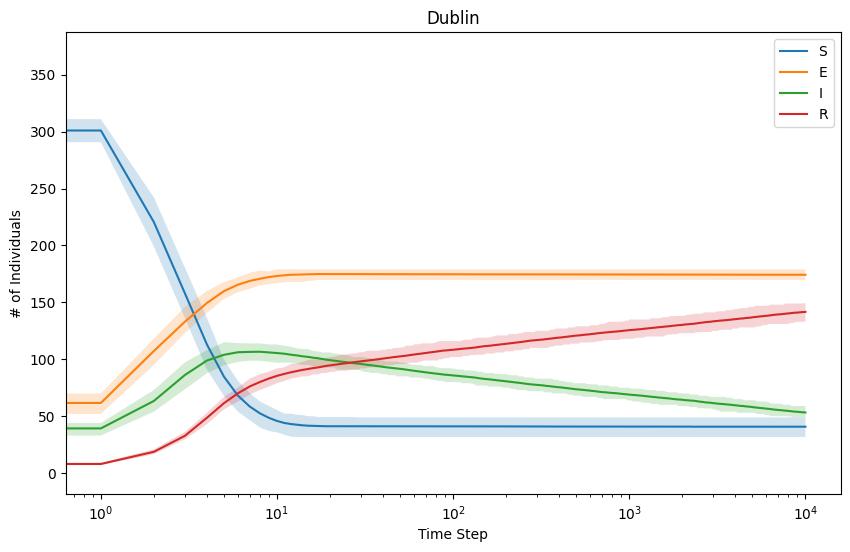

Starting Circ2


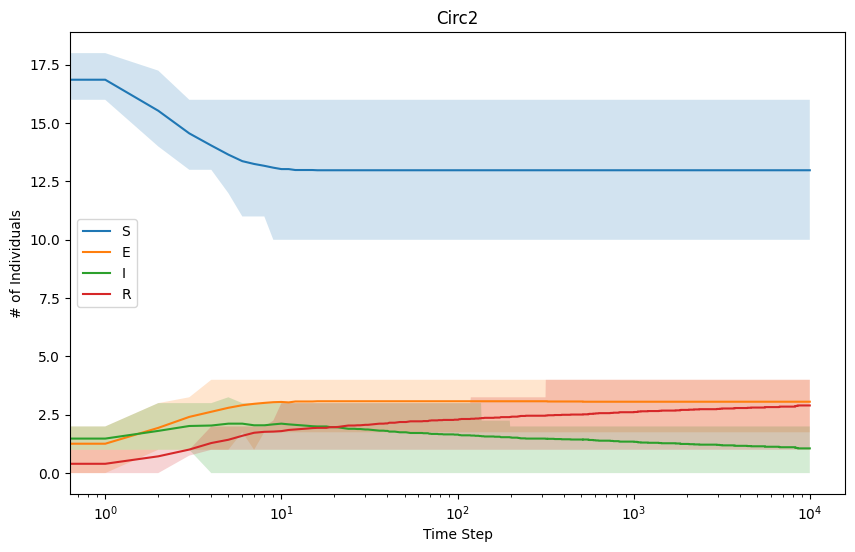

Starting Circ4


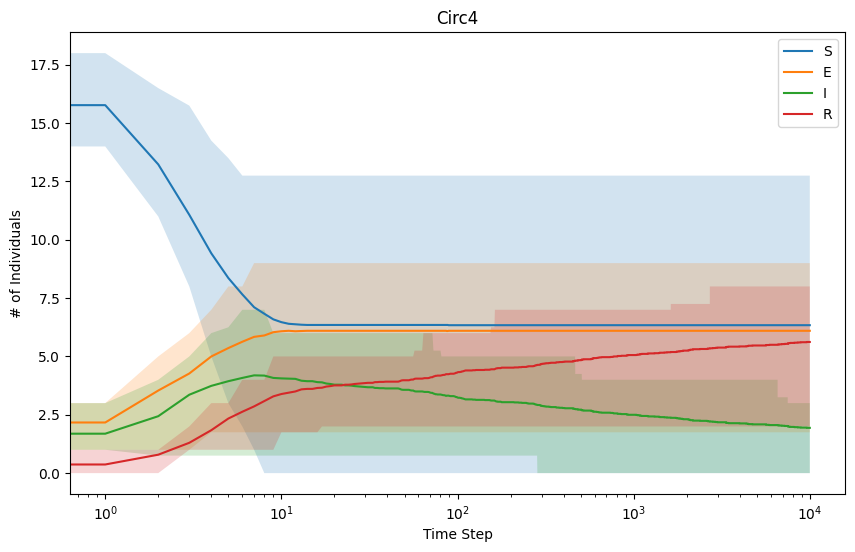

Starting Complete


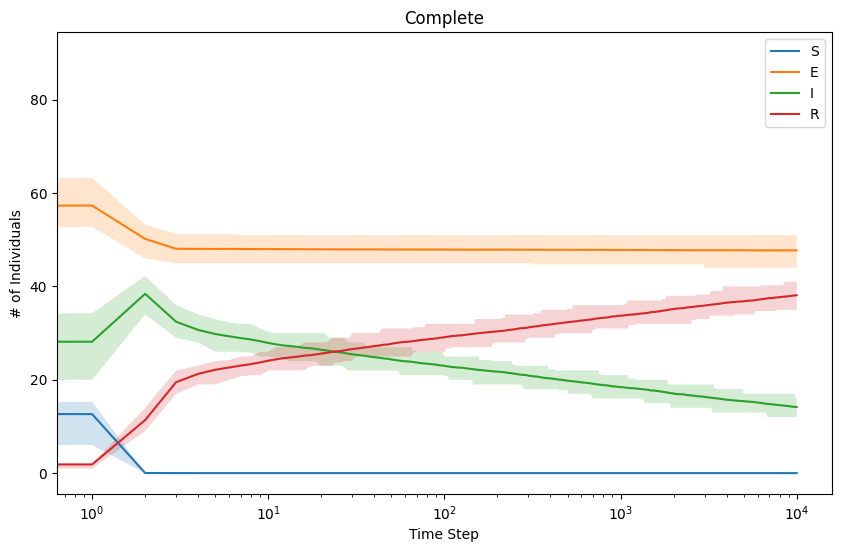

Starting Grid


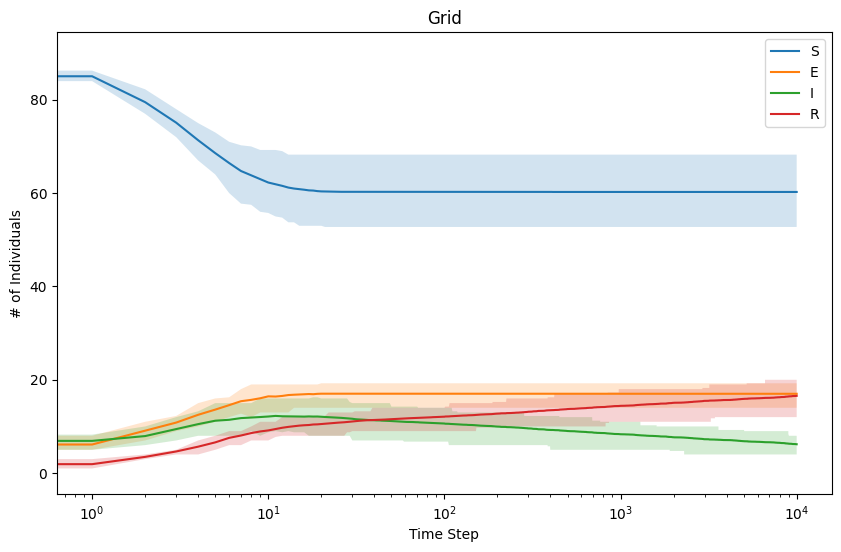

Starting Scale100


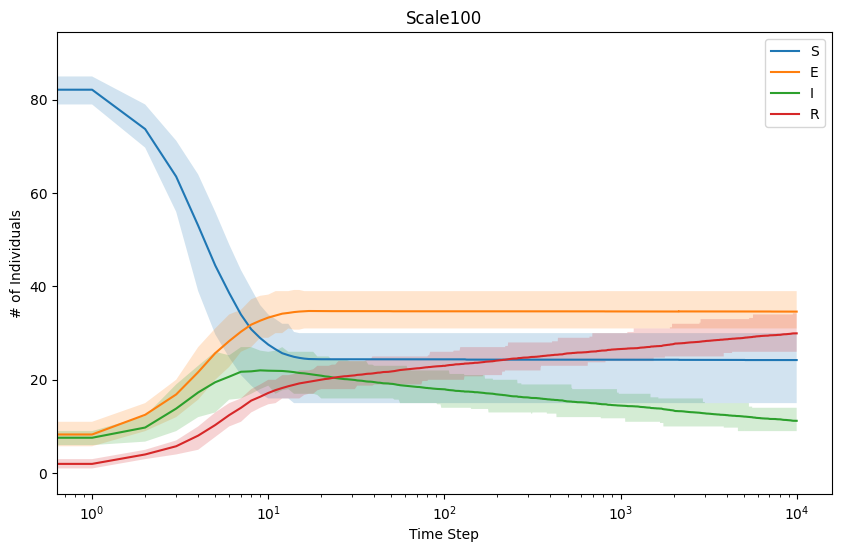

Starting Scale410


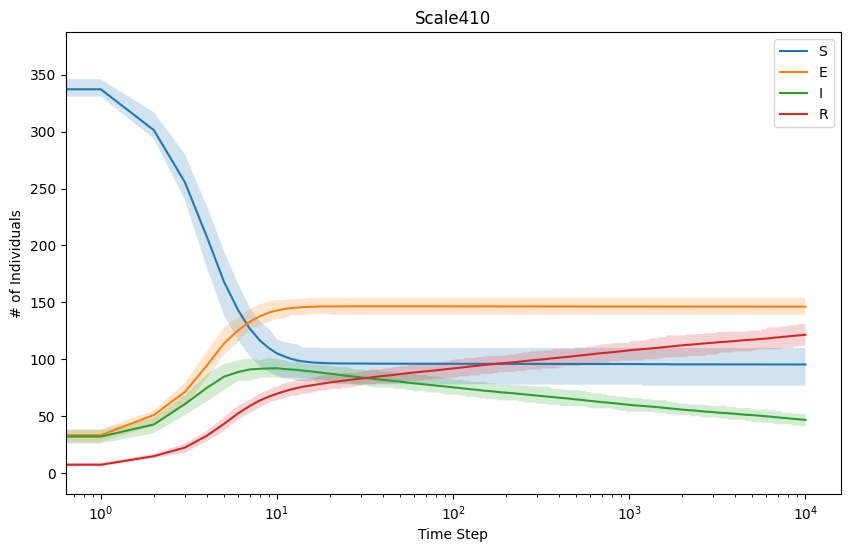

In [82]:
for network in networks.items():
    name, G = network
    print(f"Starting {name}")
    histories = [do_experiment(G, my_parameters, 10000) for _ in range(100)]
    plot_many_experiments(name, histories, logx=True)


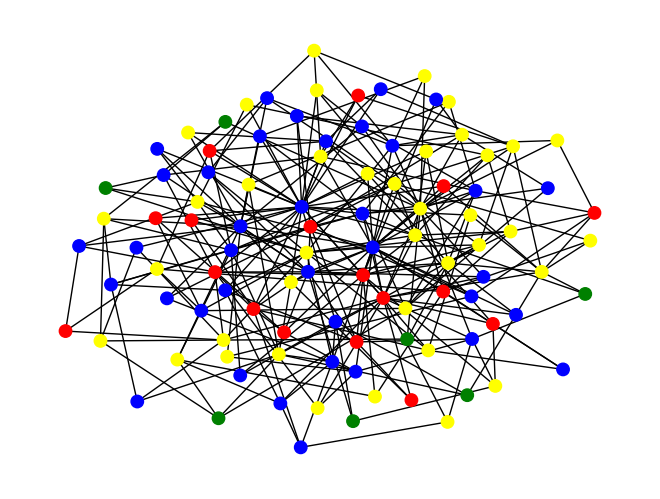

In [95]:
G = networks["Scale100"].copy()

pop = Population(G, **my_parameters)
for _ in range(40000):
    pop.update()
pop.draw()

In [70]:
import pandas as pd

def get_network_metrics(G, history):
    degrees = [d for n, d in G.degree()]
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)
    
    try:
        diameter = nx.diameter(G)
    except nx.NetworkXError:
        diameter = 'N/A'  # Graph is not connected
    
    try:
        radius = nx.radius(G)
    except nx.NetworkXError:
        radius = 'N/A'  # Graph is not connected
    
    density = nx.density(G)
    
    # Epidemic statistics
    infected = history['I']
    peak_infections = max(infected)
    time_to_peak = infected.index(peak_infections)
    
    # Find steady state (when infections drop to near zero)
    time_to_steady = len(infected) - 1
    for i in range(len(infected) - 1, -1, -1):
        if infected[i] > 1:  # More than 1 infected
            time_to_steady = i
            break
    
    uninfected = history['S'][-1]  # Final susceptible count
    
    return {
        'max_degree': max_degree,
        'avg_degree': round(avg_degree, 2),
        'diameter': diameter,
        'radius': radius,
        'density': round(density, 4),
        'time_to_peak': time_to_peak,
        'peak_infections': peak_infections,
        'time_to_steady': time_to_steady,
        'uninfected': uninfected
    }

# Run experiments and collect metrics
results_table = []
for network_name, network in networks.items():
    history = do_experiment(network, default_parameters, T=10000)
    metrics = get_network_metrics(network, history)
    metrics['network'] = network_name
    results_table.append(metrics)

# Create DataFrame and display
df = pd.DataFrame(results_table)
df = df[['network', 'max_degree', 'avg_degree', 'diameter', 'radius', 'density', 
         'time_to_peak', 'peak_infections', 'time_to_steady', 'uninfected']]

print(df.to_string(index=False))
print(df.to_markdown(index=False))


 network  max_degree  avg_degree  diameter  radius  density  time_to_peak  peak_infections  time_to_steady  uninfected
  Dublin          50       13.49         9       5   0.0330            16               56             356         111
   Circ2           4        4.00         5       5   0.2105             0                1           10000          18
   Circ4           8        8.00         3       3   0.4211            19                8              55           1
Complete          99       99.00         1       1   1.0000             6               37             148           0
    Grid           4        3.60        18      10   0.0364             4                8              23          79
Scale100          29        5.82         4       3   0.0588             8               10              33          64
Scale410          57        5.96         5       3   0.0146            43               23             119         256
| network   |   max_degree |   avg_degree |   di

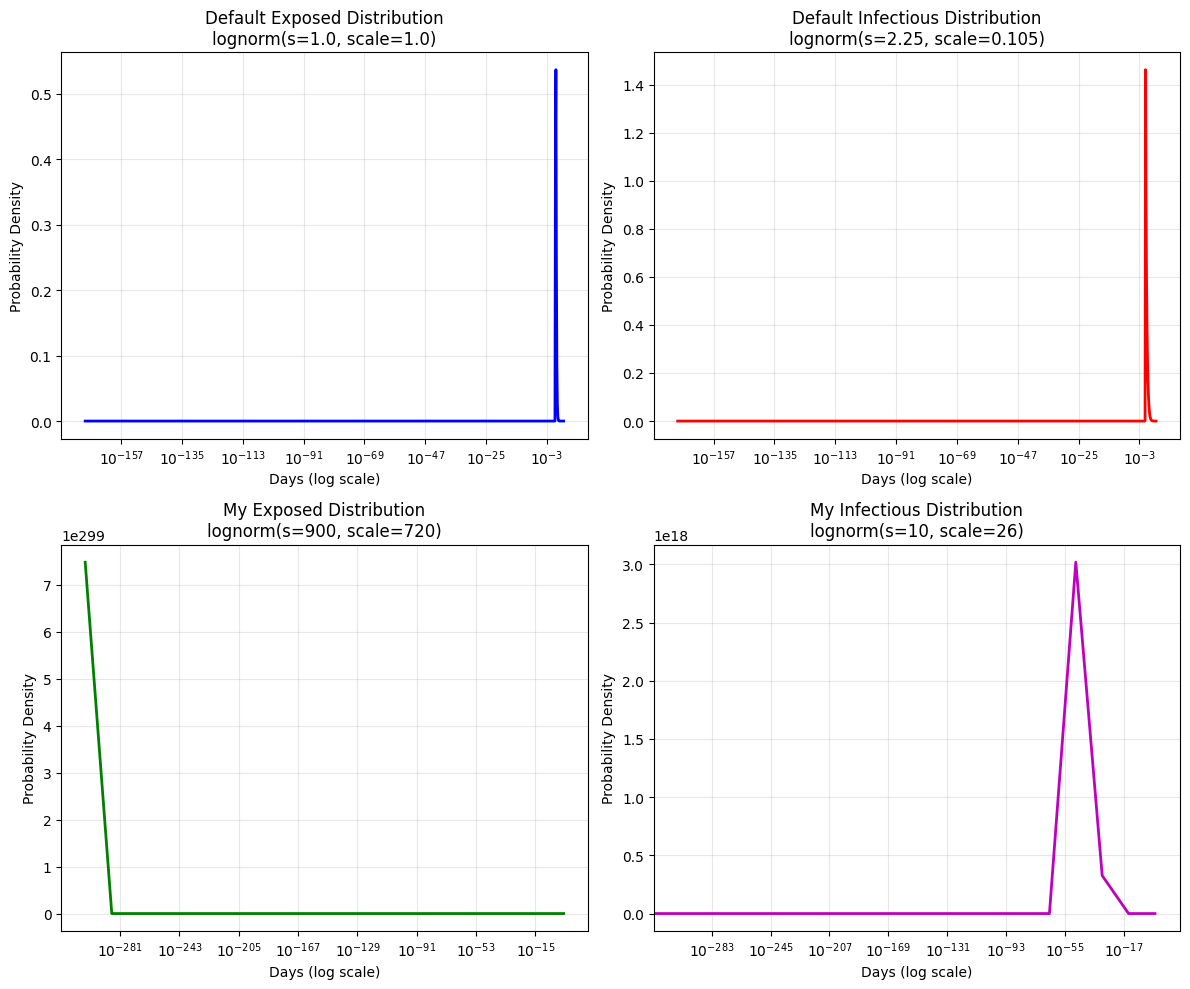

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Define your log-normal distributions
default_exposed = stats.lognorm(1.0, 1.0)
default_infectious = stats.lognorm(2.25, 0.105)
my_exposed = stats.lognorm(scale=720, s=900)
my_infectious = stats.lognorm(scale=26, s=10)

# Create x values for plotting (start from a small positive number, not 0)
x_default_exposed = np.logspace(-170, 3, 1000)
x_default_infectious = np.logspace(-170, 3, 1000)
x_my_exposed = np.logspace(-17000, 3, 1000)
x_my_infectious = np.logspace(-17000, 3, 1000)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot default exposed distribution
axes[0, 0].plot(x_default_exposed, default_exposed.pdf(x_default_exposed), 'b-', lw=2)
axes[0, 0].set_xscale('log')  # Set log scale for x-axis
axes[0, 0].set_title('Default Exposed Distribution\nlognorm(s=1.0, scale=1.0)')
axes[0, 0].set_xlabel('Days (log scale)')
axes[0, 0].set_ylabel('Probability Density')
axes[0, 0].grid(True, alpha=0.3, which='both')  # Show both major and minor gridlines

# Plot default infectious distribution
axes[0, 1].plot(x_default_infectious, default_infectious.pdf(x_default_infectious), 'r-', lw=2)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Default Infectious Distribution\nlognorm(s=2.25, scale=0.105)')
axes[0, 1].set_xlabel('Days (log scale)')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].grid(True, alpha=0.3, which='both')

# Plot your exposed distribution
axes[1, 0].plot(x_my_exposed, my_exposed.pdf(x_my_exposed), 'g-', lw=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('My Exposed Distribution\nlognorm(s=900, scale=720)')
axes[1, 0].set_xlabel('Days (log scale)')
axes[1, 0].set_ylabel('Probability Density')
axes[1, 0].grid(True, alpha=0.3, which='both')

# Plot your infectious distribution
axes[1, 1].plot(x_my_infectious, my_infectious.pdf(x_my_infectious), 'm-', lw=2)
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('My Infectious Distribution\nlognorm(s=10, scale=26)')
axes[1, 1].set_xlabel('Days (log scale)')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


In [100]:
my_exposed.pdf(10)

np.float64(4.432641959450136e-05)